# CACE-LOREM now2-fast 训练诊断

这个 notebook 用于回答三个核心问题：

1. 为什么 `fit-cace-LOREM-now2-fast.py` 训练时长显著高于 LOREM（~10h vs ~3h）。
2. 即使使用了 LOREM-like 架构，为什么仍然学不到角度信息（尤其是偶极/四极相关信号）。
3. 训练中提升 `lr_weight` 后，长程分支是否在**力学层面**真正起作用，而不只是能量偏置层面。


In [2]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

BASE = Path('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_test_noimprove')
FIT_DIR = Path('/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-LOREM/fit-cumulene')

assert BASE.exists(), f'BASE 不存在: {BASE}'
assert FIT_DIR.exists(), f'FIT_DIR 不存在: {FIT_DIR}'

def latest_file(folder: Path, pattern: str):
    files = sorted(folder.glob(pattern), key=lambda p: p.stat().st_mtime)
    return files[-1] if files else None

diag_path = latest_file(BASE, 'diagnostics_*.csv')
loss_path = latest_file(BASE, 'loss*.csv')
rmse_path = latest_file(BASE, 'rmse*.csv')
log_path = latest_file(FIT_DIR, 'log_now2_fast_*.out')

diag_path, loss_path, rmse_path, log_path

(PosixPath('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_test_noimprove/diagnostics_20260424_004227.csv'),
 PosixPath('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_test_noimprove/loss20260424_004227.csv'),
 PosixPath('/data/home/public/qiuqizhi/LOREM/my_experiments/cumulene/CACE-LOREM/CACE_LOREM_MP2_test_noimprove/rmse20260424_004227.csv'),
 PosixPath('/data/home/public/qiuqizhi/SOG-Qeq/SOG-Net/CACE-LOREM/fit-cumulene/log_now2_fast_68.out'))

In [3]:
import matplotlib as mpl
import matplotlib.font_manager as fm
# 常见中文字体候选（按优先级）
candidates = [
    "Noto Sans CJK SC",
    "Source Han Sans SC",
    "WenQuanYi Zen Hei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
]
available = {f.name for f in fm.fontManager.ttflist}
chosen = next((name for name in candidates if name in available), None)
if chosen is not None:
    mpl.rcParams["font.family"] = chosen
else:
    # 如果系统没装中文字体，这里给出提示
    print("未检测到常见中文字体，请先安装 Noto/思源黑体 等中文字体。")
# 解决负号显示为方块的问题
mpl.rcParams["axes.unicode_minus"] = False
print("当前字体：", mpl.rcParams["font.family"])

未检测到常见中文字体，请先安装 Noto/思源黑体 等中文字体。
当前字体： ['sans-serif']


In [4]:
# 覆盖字体配置：系统无中文字体时，自动下载并加载思源黑体
import urllib.request
from pathlib import Path
import matplotlib as mpl
import matplotlib.font_manager as fm

candidates = [
    "Noto Sans CJK SC",
    "Source Han Sans SC",
    "WenQuanYi Zen Hei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
]

available = {f.name for f in fm.fontManager.ttflist}
chosen = next((name for name in candidates if name in available), None)

if chosen is None:
    try:
        try:
            font_base = BASE
        except NameError:
            font_base = Path.cwd()

        font_dir = Path(font_base) / "fonts"
        font_dir.mkdir(parents=True, exist_ok=True)
        font_path = font_dir / "SourceHanSansSC-Regular.otf"

        if not font_path.exists():
            font_url = (
                "https://github.com/adobe-fonts/source-han-sans/raw/release/"
                "OTF/SimplifiedChinese/SourceHanSansSC-Regular.otf"
            )
            print(f"正在下载中文字体: {font_url}")
            urllib.request.urlretrieve(font_url, str(font_path))

        fm.fontManager.addfont(str(font_path))
        chosen = fm.FontProperties(fname=str(font_path)).get_name()
    except Exception as e:
        print(f"自动下载/加载中文字体失败: {e}")

if chosen is not None:
    mpl.rcParams["font.family"] = [chosen, "DejaVu Sans", "sans-serif"]
    print(f"中文字体启用成功: {chosen}")
else:
    mpl.rcParams["font.family"] = ["DejaVu Sans", "sans-serif"]
    print("仍未找到可用中文字体，请手动安装后重启内核。")

mpl.rcParams["axes.unicode_minus"] = False
print("当前字体：", mpl.rcParams["font.family"])


中文字体启用成功: Source Han Sans SC
当前字体： ['Source Han Sans SC', 'DejaVu Sans', 'sans-serif']


In [5]:
diag = pd.read_csv(diag_path) if diag_path else None
loss_df = pd.read_csv(loss_path) if loss_path else None
rmse_df = pd.read_csv(rmse_path) if rmse_path else None

if diag is None:
    raise FileNotFoundError('未找到 diagnostics_*.csv，无法做电荷/长短程诊断。')

diag = diag.sort_values('global_epoch').reset_index(drop=True)
display(diag.head())
display(diag.tail())
print(f'diagnostics 行数: {len(diag)}')

,global_epoch,stage,phase,stage_epoch,lr_weight,sr_weight,std_q,mean_abs_q,mean_q_mono,std_q_mono,...,std_q_quadrupole,mean_abs_q_quadrupole,mean_e_short,mean_e_long,mean_e_total,mean_abs_e_short,mean_abs_e_long,mean_abs_e_total,f_long_over_f_total,e_long_over_e_total
0,5,1,stage_1,5,1.0,1.0,0.032506,0.010180,-0.080753,0.061167,...,0.001972,0.001374,-1.676124,1.718810,0.042686,1.676124,1.718810,0.392760,0.000071,4.376231
1,10,1,stage_1,10,1.0,1.0,0.031547,0.010105,-0.079532,0.057995,...,0.002080,0.001442,-1.897346,1.718791,-0.178555,1.897346,1.718791,0.430097,0.000059,3.996288
2,15,1,stage_1,15,1.0,1.0,0.031245,0.010215,-0.080526,0.055242,...,0.002063,0.001443,-1.805700,1.718814,-0.086887,1.805700,1.718814,0.423734,0.000051,4.056349
3,20,1,stage_1,20,1.0,1.0,0.030841,0.010135,-0.079914,0.053985,...,0.002071,0.001447,-1.957544,1.718802,-0.238742,1.957544,1.718802,0.480065,0.000045,3.580352
4,25,1,stage_1,25,1.0,1.0,0.030817,0.010145,-0.080220,0.053463,...,0.002054,0.001432,-2.074957,1.718809,-0.356148,2.074957,1.718809,0.516191,0.000041,3.329792


,global_epoch,stage,phase,stage_epoch,lr_weight,sr_weight,std_q,mean_abs_q,mean_q_mono,std_q_mono,...,std_q_quadrupole,mean_abs_q_quadrupole,mean_e_short,mean_e_long,mean_e_total,mean_abs_e_short,mean_abs_e_long,mean_abs_e_total,f_long_over_f_total,e_long_over_e_total
95,480,1,stage_1,480,1.0,1.0,0.045648,0.012138,-0.101763,0.097781,...,0.001001,0.000691,-1.820941,1.719178,-0.101763,1.820941,1.719178,0.430704,0.00005,3.991558
96,485,1,stage_1,485,1.0,1.0,0.045656,0.012119,-0.101595,0.097971,...,0.001002,0.000692,-1.793761,1.719174,-0.074587,1.793761,1.719174,0.423778,0.00005,4.056776
97,490,1,stage_1,490,1.0,1.0,0.045671,0.012139,-0.101767,0.097875,...,0.001002,0.000691,-1.789840,1.719178,-0.070662,1.789840,1.719178,0.424340,0.00005,4.051421
98,495,1,stage_1,495,1.0,1.0,0.045673,0.012133,-0.101715,0.097931,...,0.001002,0.000691,-1.767561,1.719177,-0.048384,1.767561,1.719177,0.421963,0.00005,4.074233
99,500,1,stage_1,500,1.0,1.0,0.045677,0.012135,-0.101732,0.097934,...,0.001002,0.000692,-1.772186,1.719177,-0.053009,1.772186,1.719177,0.422327,0.00005,4.070726


diagnostics 行数: 100


In [6]:
# 从日志抓取 [Diag] 行，和 diagnostics 做交叉校验
diag_log_df = pd.DataFrame()
if log_path and log_path.exists():
    text = log_path.read_text(errors='ignore')
    pat = re.compile(
        r'\[Diag\]\s+epoch=(?P<global_epoch>\d+)\s+stage=(?P<stage>[\d\.]+)\s+'
        r'lr_weight=(?P<lr_weight>[\d\.]+)\s+'
        r'std\(q\)=(?P<std_q>[\deE\+\-\.]+)\s+mean\(\|q\|\)=(?P<mean_abs_q>[\deE\+\-\.]+)\s+'
        r'std\(q_dip\)=(?P<std_q_dipole>[\deE\+\-\.]+)\s+std\(q_quad\)=(?P<std_q_quadrupole>[\deE\+\-\.]+)\s+'
        r'\|\|F_long\|\|/\|\|F_total\|\|=(?P<f_long_over_f_total>[\deE\+\-\.]+)\s+'
        r'E_long/E_total=(?P<e_long_over_e_total>[\deE\+\-\.]+)'
    )
    rows = []
    for m in pat.finditer(text):
        d = m.groupdict()
        d['global_epoch'] = int(d['global_epoch'])
        for k in ['lr_weight', 'std_q', 'mean_abs_q', 'std_q_dipole', 'std_q_quadrupole', 'f_long_over_f_total', 'e_long_over_e_total']:
            d[k] = float(d[k])
        rows.append(d)
    diag_log_df = pd.DataFrame(rows).sort_values('global_epoch').reset_index(drop=True)

print(f'log 中解析到 Diag 条数: {len(diag_log_df)}')
if len(diag_log_df) > 0:
    display(diag_log_df.head())
    display(diag_log_df.tail())

log 中解析到 Diag 条数: 50


,global_epoch,stage,lr_weight,std_q,mean_abs_q,std_q_dipole,std_q_quadrupole,f_long_over_f_total,e_long_over_e_total
0,10,1.10,1.0,0.039563,0.014274,0.000815,0.001226,0.000052,4.086737
1,20,1.20,1.0,0.031343,0.011551,0.001184,0.001349,0.000056,4.184325
2,30,1.30,1.0,0.029556,0.010894,0.001253,0.001288,0.000055,4.106852
3,40,1.40,1.0,0.028684,0.010605,0.001345,0.001228,0.000056,3.957479
4,50,1.50,1.0,0.028392,0.010514,0.001382,0.001267,0.000054,4.111900


,global_epoch,stage,lr_weight,std_q,mean_abs_q,std_q_dipole,std_q_quadrupole,f_long_over_f_total,e_long_over_e_total
45,460,4.60,20.0,0.02527,0.009398,0.001691,0.001514,0.000975,1.420205
46,470,4.70,20.0,0.02527,0.009398,0.001691,0.001514,0.000975,1.420219
47,480,4.80,20.0,0.02527,0.009398,0.001691,0.001514,0.000975,1.420233
48,490,4.90,20.0,0.02527,0.009398,0.001691,0.001514,0.000975,1.420235
49,500,4.100,20.0,0.02527,0.009398,0.001691,0.001514,0.000975,1.420238


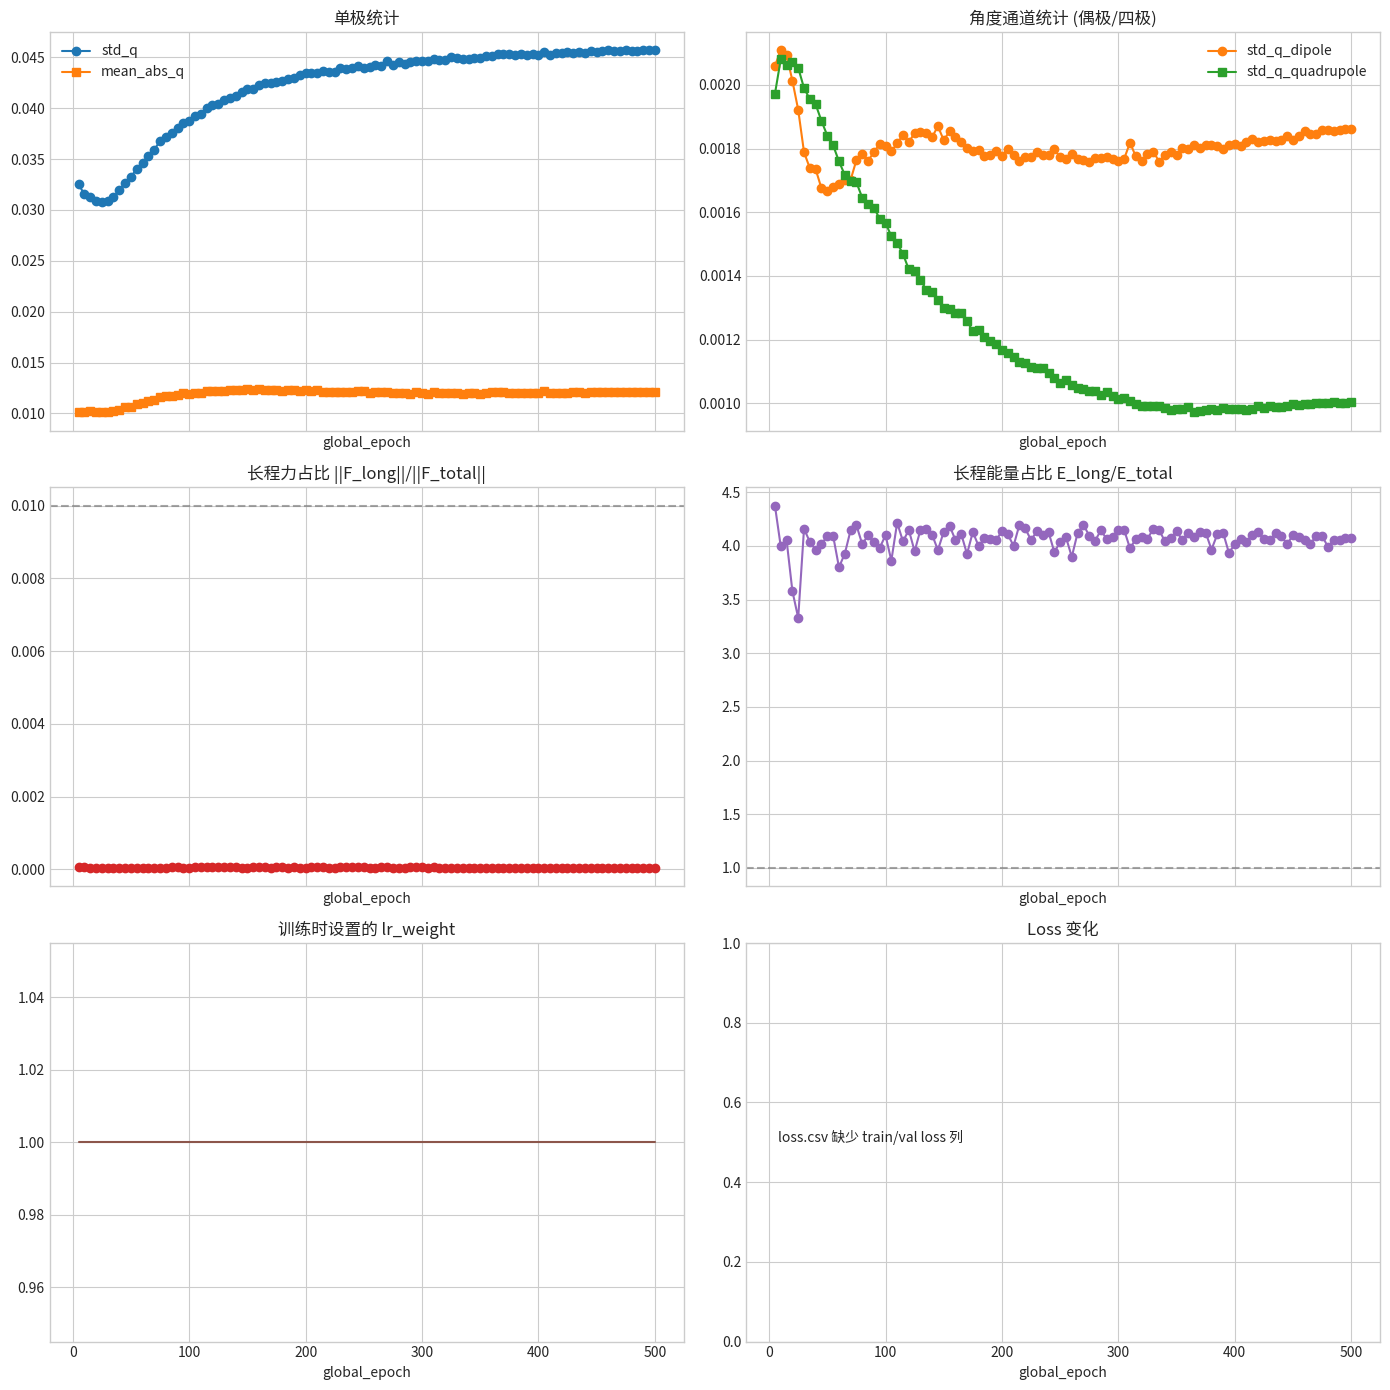

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14), sharex=True)

x = diag['global_epoch']

axes[0, 0].plot(x, diag['std_q'], marker='o', label='std_q')
axes[0, 0].plot(x, diag['mean_abs_q'], marker='s', label='mean_abs_q')
axes[0, 0].set_title('单极统计')
axes[0, 0].legend()

axes[0, 1].plot(x, diag['std_q_dipole'], marker='o', color='tab:orange', label='std_q_dipole')
axes[0, 1].plot(x, diag['std_q_quadrupole'], marker='s', color='tab:green', label='std_q_quadrupole')
axes[0, 1].set_title('角度通道统计 (偶极/四极)')
axes[0, 1].legend()

axes[1, 0].plot(x, diag['f_long_over_f_total'], marker='o', color='tab:red')
axes[1, 0].set_title('长程力占比 ||F_long||/||F_total||')
axes[1, 0].axhline(0.01, ls='--', color='gray', alpha=0.7)

axes[1, 1].plot(x, diag['e_long_over_e_total'], marker='o', color='tab:purple')
axes[1, 1].set_title('长程能量占比 E_long/E_total')
axes[1, 1].axhline(1.0, ls='--', color='gray', alpha=0.7)

axes[2, 0].step(x, diag['lr_weight'], where='post', color='tab:brown')
axes[2, 0].set_title('训练时设置的 lr_weight')

if loss_df is not None and 'val_loss' in loss_df.columns:
    axes[2, 1].plot(loss_df.index + 1, loss_df['train_loss'], label='train_loss')
    axes[2, 1].plot(loss_df.index + 1, loss_df['val_loss'], label='val_loss')
    axes[2, 1].set_title('Loss 变化')
    axes[2, 1].legend()
else:
    axes[2, 1].text(0.05, 0.5, 'loss.csv 缺少 train/val loss 列', transform=axes[2, 1].transAxes)
    axes[2, 1].set_title('Loss 变化')

for ax in axes.ravel():
    ax.set_xlabel('global_epoch')

plt.tight_layout()
plt.show()

,lr_weight,n,std_q_mean,std_q_dip_mean,std_q_quad_mean,f_ratio_mean,e_ratio_mean,f_ratio_max,e_ratio_max
0,1.0,100,0.042096,0.001808,0.001241,0.000051,4.06197,0.000071,4.376231


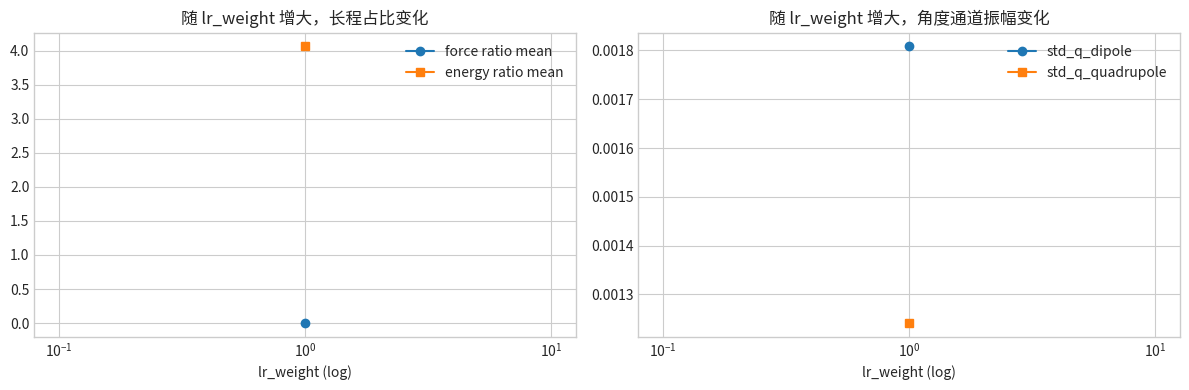

In [8]:
stage_stats = (
    diag.groupby('lr_weight')
    .agg(
        n=('global_epoch', 'count'),
        std_q_mean=('std_q', 'mean'),
        std_q_dip_mean=('std_q_dipole', 'mean'),
        std_q_quad_mean=('std_q_quadrupole', 'mean'),
        f_ratio_mean=('f_long_over_f_total', 'mean'),
        e_ratio_mean=('e_long_over_e_total', 'mean'),
        f_ratio_max=('f_long_over_f_total', 'max'),
        e_ratio_max=('e_long_over_e_total', 'max')
    )
    .reset_index()
)
display(stage_stats)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(stage_stats['lr_weight'], stage_stats['f_ratio_mean'], marker='o', label='force ratio mean')
ax[0].plot(stage_stats['lr_weight'], stage_stats['e_ratio_mean'], marker='s', label='energy ratio mean')
ax[0].set_xscale('log')
ax[0].set_title('随 lr_weight 增大，长程占比变化')
ax[0].set_xlabel('lr_weight (log)')
ax[0].legend()

ax[1].plot(stage_stats['lr_weight'], stage_stats['std_q_dip_mean'], marker='o', label='std_q_dipole')
ax[1].plot(stage_stats['lr_weight'], stage_stats['std_q_quad_mean'], marker='s', label='std_q_quadrupole')
ax[1].set_xscale('log')
ax[1].set_title('随 lr_weight 增大，角度通道振幅变化')
ax[1].set_xlabel('lr_weight (log)')
ax[1].legend()

plt.tight_layout()
plt.show()

,std_q,std_q_dipole,std_q_quadrupole,f_long_over_f_total,e_long_over_e_total,lr_weight
std_q,1.000000,-0.147784,-0.993309,0.226693,0.301096,NaN
std_q_dipole,-0.147784,1.000000,0.192678,0.353170,-0.147986,NaN
std_q_quadrupole,-0.993309,0.192678,1.000000,-0.172117,-0.292889,NaN
f_long_over_f_total,0.226693,0.353170,-0.172117,1.000000,0.447808,NaN
e_long_over_e_total,0.301096,-0.147986,-0.292889,0.447808,1.000000,NaN
lr_weight,NaN,NaN,NaN,NaN,NaN,NaN


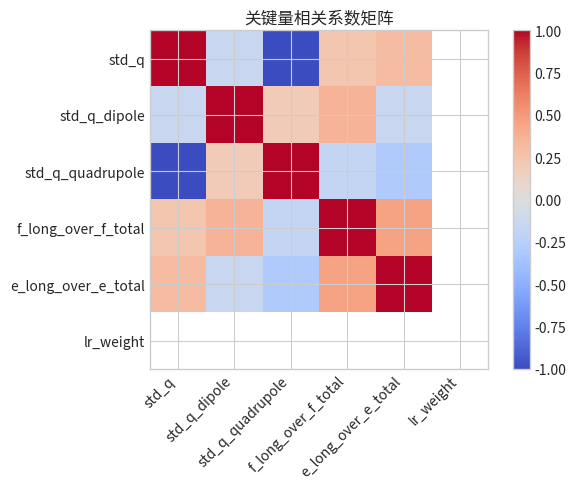

In [9]:
# 简单相关性：角度信号振幅 与 长程力贡献
corr_cols = ['std_q', 'std_q_dipole', 'std_q_quadrupole', 'f_long_over_f_total', 'e_long_over_e_total', 'lr_weight']
corr = diag[corr_cols].corr(numeric_only=True)
display(corr)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_cols)
ax.set_title('关键量相关系数矩阵')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [10]:
# 从日志估计耗时：统计带时间戳行的首尾差值
from datetime import datetime

elapsed_hours = None
if log_path and log_path.exists():
    ts_pat = re.compile(r'(\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}\.\d{3})')
    ts = [datetime.strptime(m.group(1), '%Y-%m-%d %H:%M:%S.%f') for m in ts_pat.finditer(log_path.read_text(errors='ignore'))]
    if len(ts) >= 2:
        elapsed_hours = (ts[-1] - ts[0]).total_seconds() / 3600.0

print(f'估计日志覆盖时长(小时): {elapsed_hours}')
if elapsed_hours is not None and diag is not None and len(diag) > 1:
    max_epoch = diag['global_epoch'].max()
    print(f'最大 global_epoch: {max_epoch}')
    print(f'粗略每100 epoch耗时(小时): {elapsed_hours / max(max_epoch, 1) * 100:.2f}')

估计日志覆盖时长(小时): 11.090065833333334
最大 global_epoch: 500
粗略每100 epoch耗时(小时): 2.22


In [11]:
def slope(y, x):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2:
        return np.nan
    p = np.polyfit(x, y, 1)
    return p[0]

summary = {
    'std_q_dipole_median': float(diag['std_q_dipole'].median()),
    'std_q_quadrupole_median': float(diag['std_q_quadrupole'].median()),
    'f_ratio_median': float(diag['f_long_over_f_total'].median()),
    'e_ratio_median': float(diag['e_long_over_e_total'].median()),
    'f_ratio_slope': float(slope(diag['f_long_over_f_total'], diag['global_epoch'])),
    'dipole_slope': float(slope(diag['std_q_dipole'], diag['global_epoch'])),
    'quad_slope': float(slope(diag['std_q_quadrupole'], diag['global_epoch']))
}
summary

{'std_q_dipole_median': 0.00179982082272995,
 'std_q_quadrupole_median': 0.0010682786579047,
 'f_ratio_median': 5.10176725017198e-05,
 'e_ratio_median': 4.077482538293242,
 'f_ratio_slope': -7.759474047017612e-10,
 'dipole_slope': 1.0833376049105126e-09,
 'quad_slope': -2.008226703730284e-06}

In [12]:
diagnosis = []

if summary['std_q_dipole_median'] < 0.01 and summary['std_q_quadrupole_median'] < 0.01:
    diagnosis.append('偶极/四极通道的统计振幅整体偏小，说明角度相关自由度没有被充分激活。')

if summary['f_ratio_median'] < 0.01:
    diagnosis.append('长程力占比长期低于 1%，长程分支对力监督几乎没有梯度主导权。')

if summary['e_ratio_median'] > 1.0 and summary['f_ratio_median'] < 0.01:
    diagnosis.append('出现“E_long/E_total 高但 F_long/F_total 低”的结构，通常表示长程分支更像能量偏置项，而非决定几何梯度的项。')

if summary['dipole_slope'] <= 0 and summary['quad_slope'] <= 0:
    diagnosis.append('随训练推进，偶极/四极振幅没有上升趋势，说明提高 lr_weight 并未持续增强角度信息表达。')

if summary['f_ratio_slope'] <= 0:
    diagnosis.append('即便 staged lr_weight 提升，长程力占比趋势仍不升反降（或近零变化），说明“加权”没有转化为“力学贡献”。')

if elapsed_hours is not None:
    diagnosis.append(f'日志估计总训练时长约 {elapsed_hours:.2f} 小时；若明显高于 LOREM，通常还包含 CACE 路径下更重的特征构造与双分支反复前向开销。')

if not diagnosis:
    diagnosis.append('当前统计未触发明显异常阈值，建议结合二面角曲线误差与分构型分段诊断进一步确认。')

print('=== 自动诊断结论 ===')
for i, item in enumerate(diagnosis, 1):
    print(f'{i}. {item}')

print('\n=== 关键统计 ===')
for k, v in summary.items():
    print(f'{k}: {v:.6g}')

=== 自动诊断结论 ===
1. 偶极/四极通道的统计振幅整体偏小，说明角度相关自由度没有被充分激活。
2. 长程力占比长期低于 1%，长程分支对力监督几乎没有梯度主导权。
3. 出现“E_long/E_total 高但 F_long/F_total 低”的结构，通常表示长程分支更像能量偏置项，而非决定几何梯度的项。
4. 即便 staged lr_weight 提升，长程力占比趋势仍不升反降（或近零变化），说明“加权”没有转化为“力学贡献”。
5. 日志估计总训练时长约 11.09 小时；若明显高于 LOREM，通常还包含 CACE 路径下更重的特征构造与双分支反复前向开销。

=== 关键统计 ===
std_q_dipole_median: 0.00179982
std_q_quadrupole_median: 0.00106828
f_ratio_median: 5.10177e-05
e_ratio_median: 4.07748
f_ratio_slope: -7.75947e-10
dipole_slope: 1.08334e-09
quad_slope: -2.00823e-06


## 结果解读建议

- 先看 `std_q_dipole/std_q_quadrupole` 是否在后期显著抬升；若始终很小，角度通道就是“结构在、信号不在”。
- 再看 `f_long_over_f_total`：若接近 0，即使 `E_long/E_total` 很高，也往往无法改善几何相关任务（如二面角势垒形状）。
- 如果 `lr_weight` 提升后，`f_long_over_f_total` 没有同步提升，说明当前损失配比/梯度路径仍偏向短程分支。
- 对比 LOREM 时建议优先对齐：每步耗时拆解（数据加载、前向、诊断额外前向）、有效 batch、每 epoch 样本吞吐，以及是否存在额外重复前向（例如诊断中再次跑 LR）。
